<a href="https://colab.research.google.com/github/Mamun-75/Python-For-Data-Science-and-Machine-Learning/blob/main/Decision_Trees_and_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [205]:
df = pd.read_csv('kyphosis.csv')  # this dataset essentially represents a number of patients who had kyphosis which is a spinal condition and then they had an operation

# and the operation was  a corrective spinal surgery and the state of frame represents whether or not the kyphosis condition was absent or present after the operation
# age is in month(parients are mainly childen)
# number is the number of vertebrae involed in the operation
# the start was the number of the first or top most vertebrae that was operated on

In [206]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


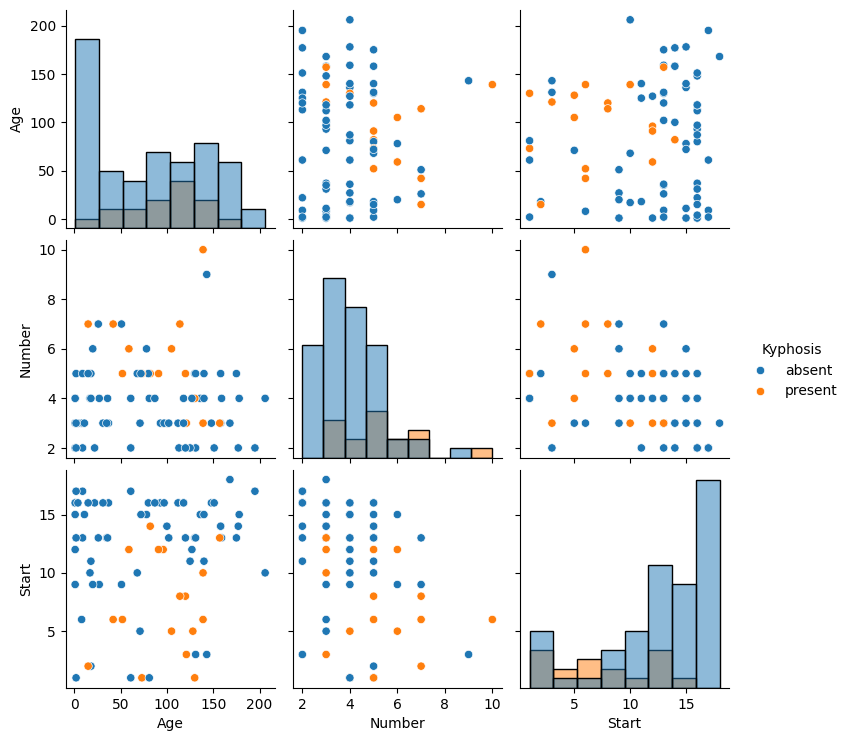

In [208]:
sns.pairplot(df, hue = 'Kyphosis', diag_kind = 'hist')

In [209]:
from sklearn.model_selection import train_test_split

In [210]:
X = df.drop('Kyphosis', axis = 1)

In [211]:
y = df['Kyphosis']

In [212]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=101)

In [213]:
from sklearn.tree import DecisionTreeClassifier

In [214]:
dtree = DecisionTreeClassifier()

In [215]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [216]:
predictions = dtree.predict(X_test)

In [217]:
predictions

array(['absent', 'present', 'present', 'absent', 'absent', 'absent',
       'absent', 'present', 'absent', 'absent', 'absent', 'absent',
       'present', 'present', 'present', 'absent', 'absent', 'absent',
       'absent', 'absent', 'absent', 'absent', 'present', 'absent',
       'absent'], dtype=object)

In [218]:
from sklearn.metrics import classification_report, confusion_matrix

In [219]:
print(classification_report(y_test, predictions))
print('\n')
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

      absent       0.67      0.71      0.69        17
     present       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25



[[12  5]
 [ 6  2]]


In [220]:
from sklearn.ensemble import RandomForestClassifier

In [221]:
rfc = RandomForestClassifier(n_estimators = 200)

In [222]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [223]:
rfc_prediction = rfc.predict(X_test)

In [224]:
print(classification_report(y_test, rfc_prediction))
print('\n')
print(confusion_matrix(y_test, rfc_prediction))

              precision    recall  f1-score   support

      absent       0.74      1.00      0.85        17
     present       1.00      0.25      0.40         8

    accuracy                           0.76        25
   macro avg       0.87      0.62      0.62        25
weighted avg       0.82      0.76      0.71        25



[[17  0]
 [ 6  2]]


In [225]:
##  when dataaset is being larger a random forest will better and better than decision tree

In [229]:
df['Kyphosis'].value_counts()  # unbalanced

,count
Kyphosis,
absent,64
present,17


In [231]:
### plotting tree
# we dont usually plot tree,  just for learning purpose

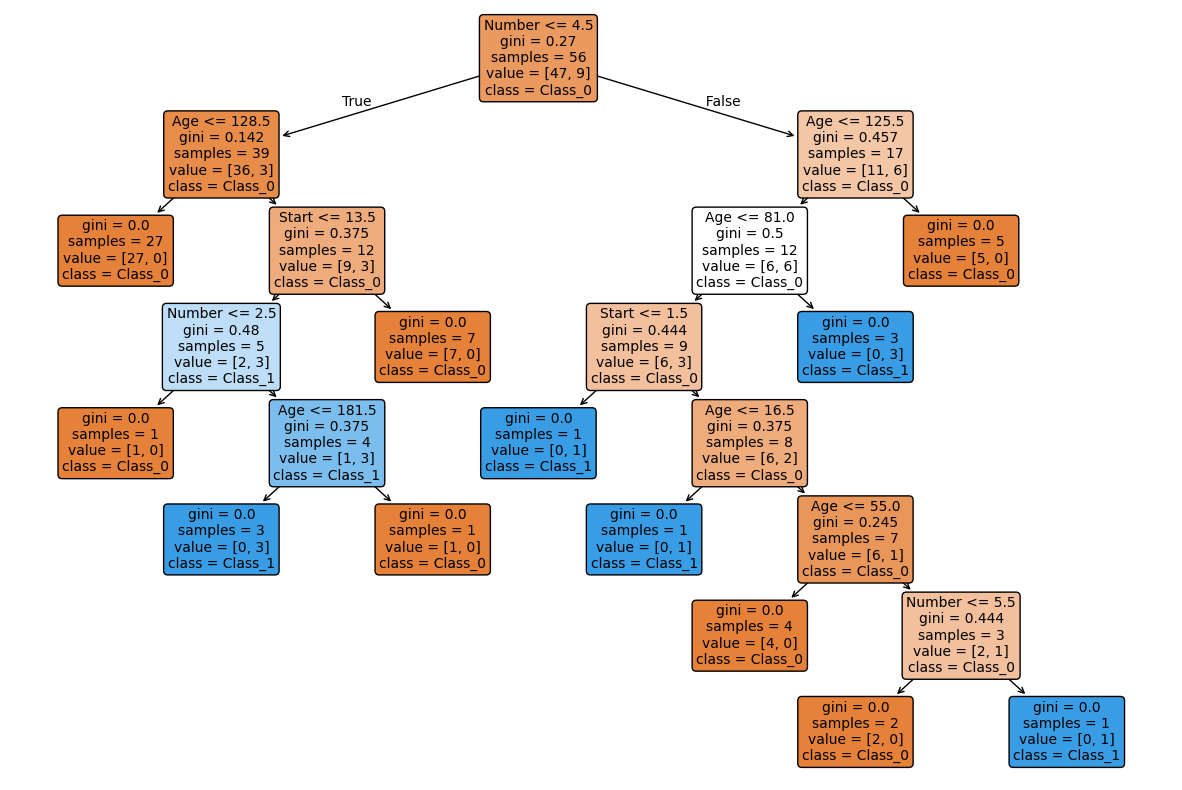

In [240]:
from sklearn.tree import plot_tree

# তোমার ডেটাসেটের ফিচারগুলোর নাম (যেটা তুমি লিস্ট করেছো)
features = ['Age', 'Number', 'Start']
# যদি টার্গেট ক্লাসগুলোর নাম জানা থাকে (যেমন: 'Yes', 'No'), না থাকলে None দিতে পারো
class_names = ['Class_0', 'Class_1']

# Figure সাইজ বড় করা, যাতে গাছটা পরিষ্কার দেখা যায়
plt.figure(figsize=(15, 10))

# dtree হলো তোমার ট্রেইন করা Decision Tree মডেলটা
plot_tree(dtree,
          feature_names=features,
          class_names=class_names,
          filled=True,      # নোডগুলোতে রঙ দেওয়ার জন্য
          rounded=True,     # নোডের চারপাশ গোলাকার করার জন্য
          fontsize=10)      # লেখার সাইজ ঠিক করার জন্য

# ছবিটা স্ক্রিনে দেখানোর জন্য
plt.show()